# ЛР 3.2: Методы опорных векторов

## Теоретическая часть

## Линейно разделимые данные

In [353]:
import numpy as np
import seaborn as sns
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.datasets import make_circles
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score


X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.4)

## Визуализируем сгенерированный датасет

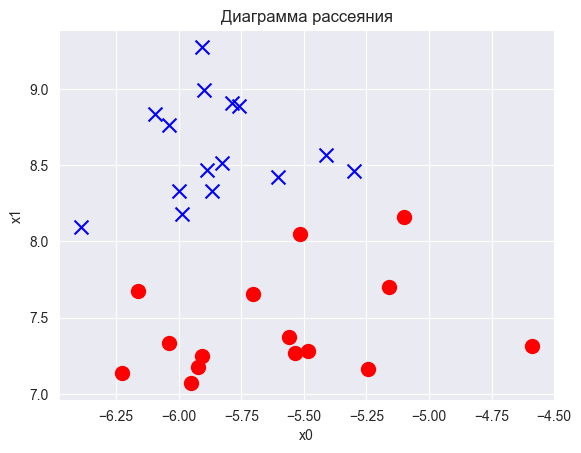

In [354]:
plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

## Создадим и обучим модель SVC

In [355]:
svm_linear = SVC(kernel='linear', C=100)
svm_linear.fit(X, y)

,C,100
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [356]:
print("Коэффициенты: ", *svm_linear.coef_)

Коэффициенты:  [-2.49920793  6.14683189]


In [357]:
print("Свободный коэффициент: ", *svm_linear.intercept_)

Свободный коэффициент:  -64.25339880278436


## Строим границу принятия решения

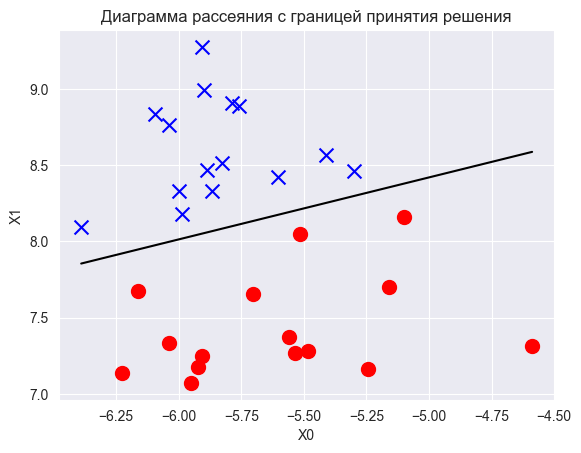

In [358]:
X0 = np.linspace(X[:, 0].min(),X[:, 0].max(), X.shape[0])

plt.plot(X0,-svm_linear.intercept_[0]/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0, c='k')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c границей принятия решения")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

In [359]:
print("Координаты опорных векторов: \n", svm_linear.support_vectors_)

Координаты опорных векторов: 
 [[-5.51629264  8.04763857]
 [-5.30025769  8.46071981]
 [-5.9879581   8.18112559]]


In [360]:
print("Индексы опорных векторов в исходном датасете: ", *svm_linear.support_)

print("Количество опорных векторов: ", svm_linear.n_support_)

Индексы опорных векторов в исходном датасете:  0 8 29
Количество опорных векторов:  [1 2]


## Визуализация опорных векторов

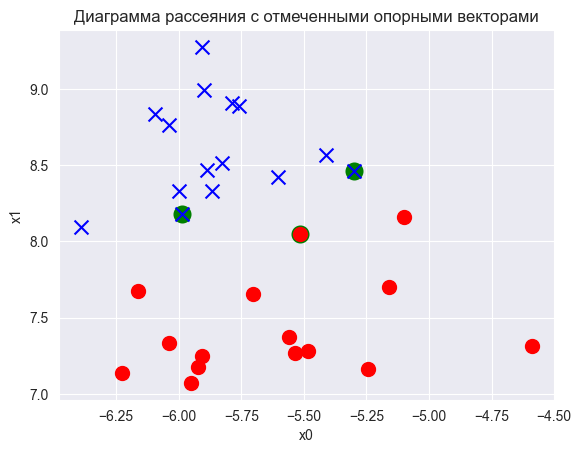

In [361]:
plt.scatter(svm_linear.support_vectors_[:, 0],svm_linear.support_vectors_[:, 1], linewidth=7, facecolors='green')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c отмеченными опорными векторами")
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

## С границей области зазора

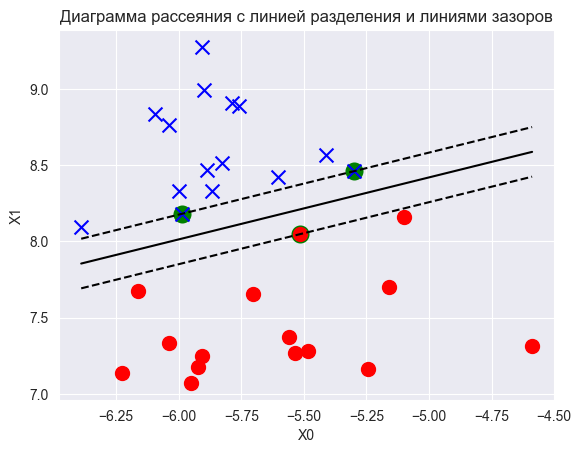

In [362]:
plt.plot(X0,-svm_linear.intercept_[0]/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0, c='k')

plt.plot(X0,(-svm_linear.intercept_[0]-1)/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0,linestyle='--', c='k')
plt.plot(X0,(-svm_linear.intercept_[0]+1)/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0,linestyle='--', c='k')

plt.scatter(svm_linear.support_vectors_[:, 0],svm_linear.support_vectors_[:, 1], linewidth=7, facecolors='green')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c линией разделения и линиями зазоров")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

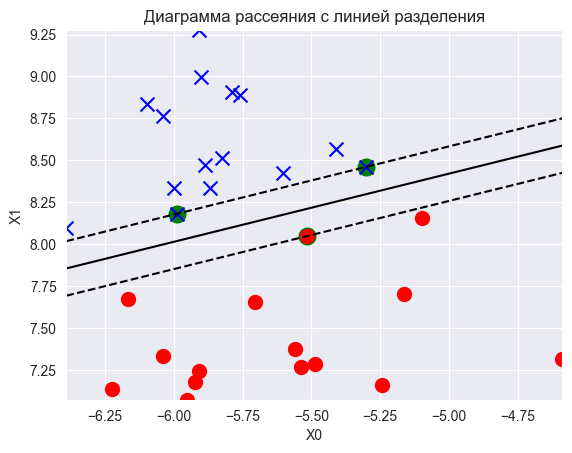

In [363]:
X0 = np.linspace(X[:, 0].min(), X[:, 0].max(), X.shape[0])
X1 = np.linspace(X[:, 1].min(), X[:, 1].max(), X.shape[0])

X0_grid, X1_grid = np.meshgrid(X0, X1)
Z = svm_linear.intercept_[0] + svm_linear.coef_[0][0] * X0_grid +  svm_linear.coef_[0][1] * X1_grid
plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])

plt.scatter(svm_linear.support_vectors_[:, 0],svm_linear.support_vectors_[:, 1], linewidth=7, facecolors='green')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c линией разделения")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

## Функция для диаграмм с линией разделения и зазором

In [364]:
def plot_decision_regions(X, y, model):
    plt.scatter(model.support_vectors_[:, 0],model.support_vectors_[:, 1], linewidth=7, facecolors='green')

    plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
    plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

    X0 = np.linspace(X[:, 0].min(),X[:, 0].max(), X.shape[0])
    X1 = np.linspace(X[:, 1].min(),X[:, 1].max(), X.shape[0])

    X0_grid, X1_grid = np.meshgrid(X0, X1)
    Z = model.decision_function(np.array([X0_grid.ravel(), X1_grid.ravel()]).T).reshape(X0_grid.shape)
    plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])
    plt.contourf(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], alpha=0.5)

    plt.title("Диаграмма рассеяния c линией разделения и зазором")
    plt.xlabel('X0')
    plt.ylabel('X1')
    plt.show()

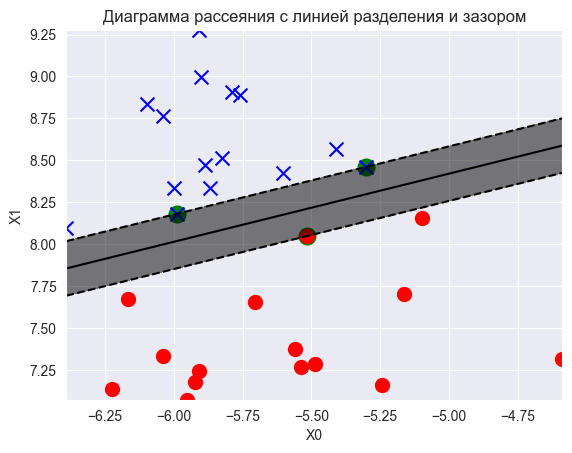

In [365]:
plot_decision_regions(X, y, svm_linear)

## Оценка качества модели

In [366]:
y_pred =  svm_linear.predict(X)
print("Точность: ", metrics.accuracy_score(y, y_pred))

Точность:  1.0


<Axes: >

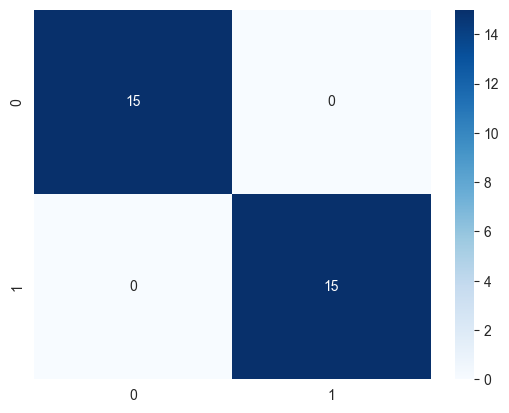

In [367]:
sns.heatmap(metrics.confusion_matrix(y, y_pred), annot=True, fmt='d', cmap='Blues') # Оси y = true; x = predicted
# TP - FP
# TN - FN

In [368]:
metrics.confusion_matrix(y, y_pred)

array([[15,  0],
       [ 0, 15]])

## Проверка работы модели созданием новой точки данных

In [369]:
observation_new = [[-5.25, 7.5]]

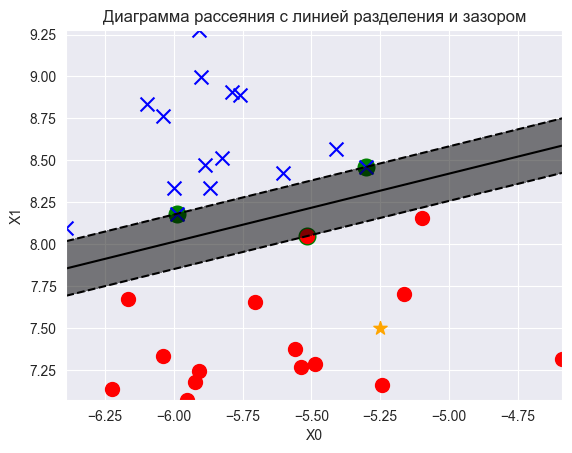

In [370]:
plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', s=100, color='orange')
plot_decision_regions(X, y, svm_linear)

In [371]:
svm_linear.decision_function(observation_new)

array([-5.03131797])

In [372]:
svm_linear.predict(observation_new)

array([0])

## Линейно неразделимые данные с зазором

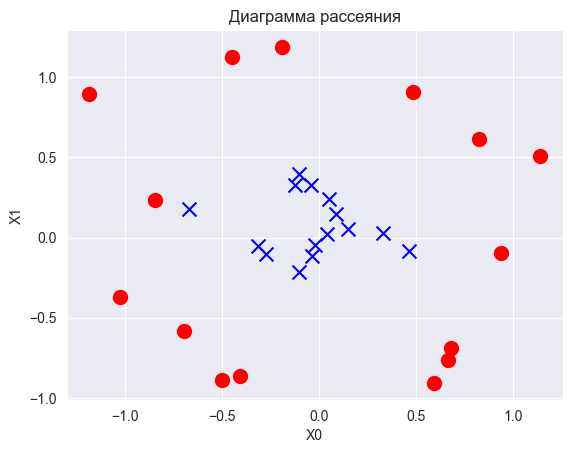

In [373]:
X, y = make_circles(n_samples=30, random_state=5, factor=.1, noise=.2)

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

### Обучим модель с линейно неразделимым датасетом

In [374]:
svm_rbf = SVC(kernel='rbf', C=100).fit(X, y)

In [375]:
print("Количество опорных векторов: ", svm_rbf.n_support_)
print("Опорные вектора: ",svm_rbf.support_)
print("Координаты опорных векторов: ", svm_rbf.support_vectors_)

Количество опорных векторов:  [6 2]
Опорные вектора:  [11 20 21 23 28 29 25 27]
Координаты опорных векторов:  [[ 0.9388294  -0.09554628]
 [-0.84682371  0.23287306]
 [-0.19166925  1.18895776]
 [-0.69539045 -0.58523359]
 [ 0.68060508 -0.68615145]
 [ 0.48354792  0.91063288]
 [-0.66975235  0.17866445]
 [ 0.46427295 -0.08540628]]


## Визуализируем

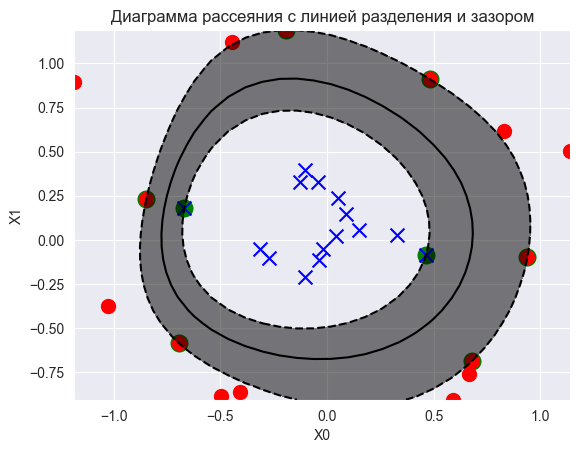

In [376]:
plot_decision_regions(X, y, svm_rbf)

## Метрики модели

In [377]:
y_pred_c = svm_rbf.predict(X)
print("Точность: ", metrics.accuracy_score(y, y_pred_c))

Точность:  1.0


<Axes: >

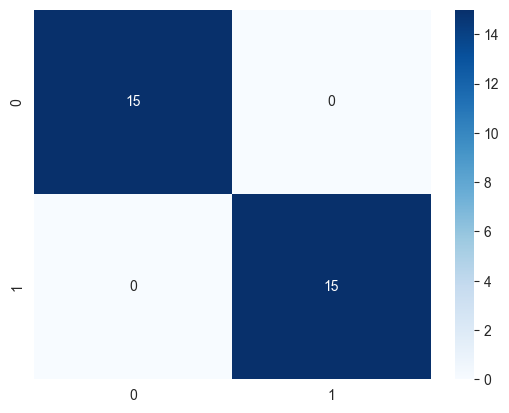

In [378]:
sns.heatmap(metrics.confusion_matrix(y, y_pred_c), annot=True, fmt='d', cmap='Blues') # Оси y = true; x = predicted
# TP - FP
# TN - FN

In [379]:
metrics.confusion_matrix(y, y_pred_c)

array([[15,  0],
       [ 0, 15]])

## Данные без зазора

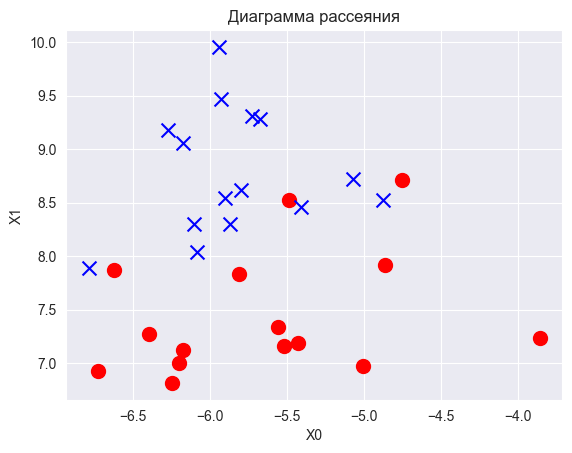

In [380]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.7)

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

## Создадим и обучим модель

In [381]:
svm_poly = SVC(kernel='poly', degree=4, C=2).fit(X, y)

## Визуализируем

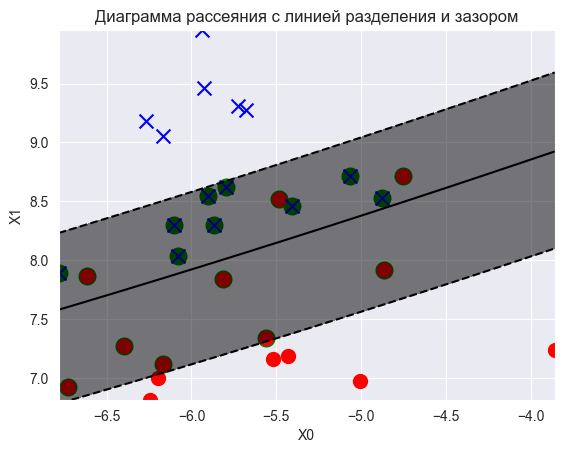

In [382]:
plot_decision_regions(X, y, svm_poly)

In [383]:
print("Опорные вектора: ", svm_poly.n_support_)

Опорные вектора:  [9 9]


## Метрики

In [384]:
y_pred_p = svm_poly.predict(X)
print("Точность: ", metrics.accuracy_score(y, y_pred_p))

Точность:  0.9


<Axes: >

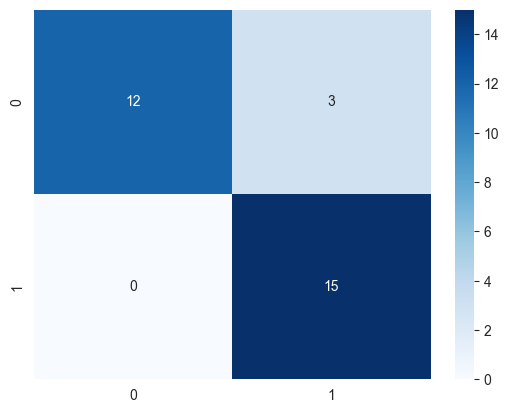

In [385]:
sns.heatmap(metrics.confusion_matrix(y, y_pred_p), annot=True, fmt='d', cmap='Blues') # Оси y = true; x = predicted
# TP - FP
# TN - FN

In [386]:
metrics.confusion_matrix(y, y_pred_p)

array([[12,  3],
       [ 0, 15]])

# =======================================================================================

# **Самостоятельные задания**

## 1. Различные значения аргумента C класса SVC

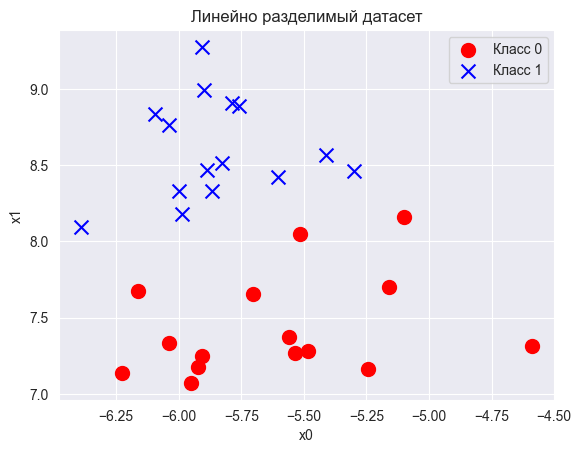

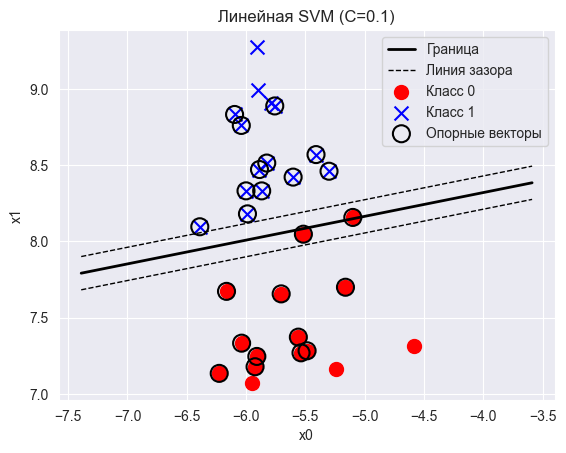

C = 0.1 — число опорных векторов: 24

================================================================================>



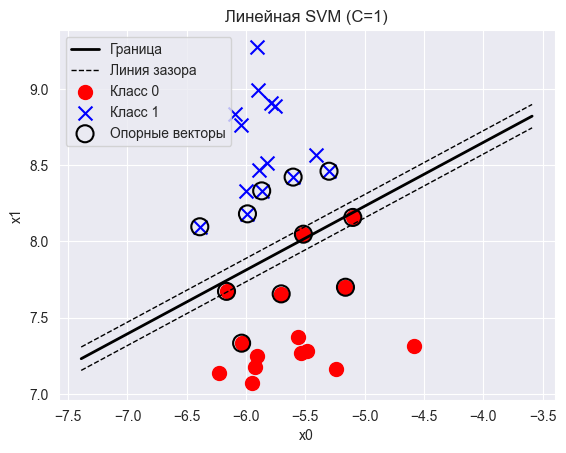

C = 1 — число опорных векторов: 11

================================================================================>



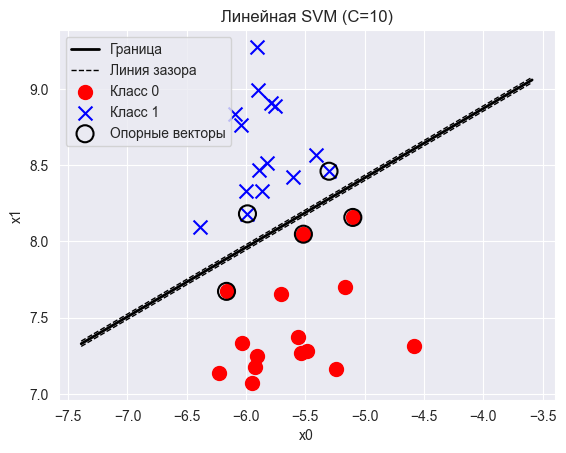

C = 10 — число опорных векторов: 5

================================================================================>



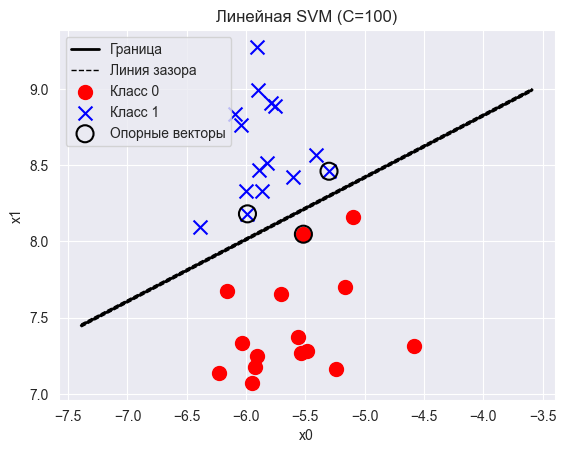

C = 100 — число опорных векторов: 3

================================================================================>



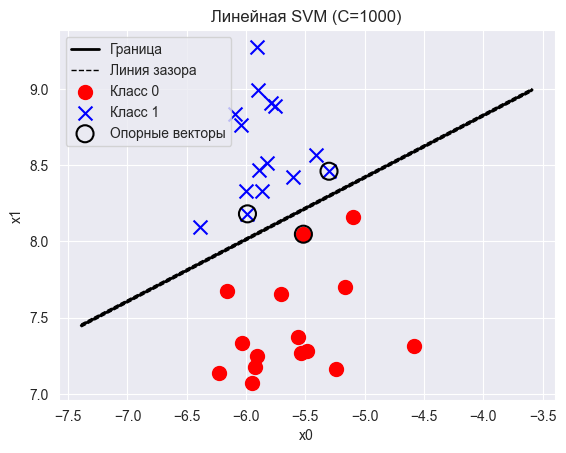

C = 1000 — число опорных векторов: 3

================================================================================>



In [387]:
# Генерируем линейно разделимый датасет
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.4)

# Визуализируем исходные точки
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], marker='o', c='r', s=100, label='Класс 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], marker='x', c='b', s=100, label='Класс 1')
plt.title("Линейно разделимый датасет")
plt.xlabel('x0')
plt.ylabel('x1')
plt.legend()
plt.show()



C_values = [0.1, 1, 10, 100, 1000] # C - регулирует мягкость зазора между данными, чем больше C тем строже зазор и меньше, но без попадания точек в зазор

for C_value in C_values:
    svm = SVC(kernel='linear', C=C_value)
    svm.fit(X, y)

    w = svm.coef_[0]
    b = svm.intercept_[0]
    w_norm = np.linalg.norm(w)
    margin = 1 / w_norm

    # Создаем линию для границы
    X_plot = np.linspace(X[:,0].min() - 1, X[:,0].max() + 1, 200)
    decision_boundary = -(w[0] * X_plot + b) / w[1]

    # Вектор нормали для построения линий зазора
    shift = margin * w / w_norm

    # Линия зазора + и -
    decision_boundary_plus = -(w[0] * X_plot + b + shift[0]) / w[1]
    decision_boundary_minus = -(w[0] * X_plot + b - shift[0]) / w[1]

    plt.figure()
    # Граница разделения
    plt.plot(X_plot, decision_boundary, 'k-', linewidth=2, label='Граница')
    # Линии зазора
    plt.plot(X_plot, decision_boundary_plus, 'k--', linewidth=1, label='Линия зазора')
    plt.plot(X_plot, decision_boundary_minus, 'k--', linewidth=1)

    # исходные данные
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], c='r', marker='o', s=100, label='Класс 0')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='b', marker='x', s=100, label='Класс 1')

    # Опорные вектора
    plt.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1], s=150, facecolors='none',
                edgecolors='k', linewidth=1.5, label='Опорные векторы')

    plt.title(f'Линейная SVM (C={C_value})')
    plt.xlabel('x0')
    plt.ylabel('x1')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"C = {C_value} — число опорных векторов: {len(svm.support_)}")
    print()
    print("================================================================================>")
    print()

## 2. Движение точки нового предсказания

Исходная точка по координатам [-5.25, 7.5] — предсказанный класс: 0
Точка за границей вне зазора по координатам [-5.25, 8.6] — предсказанный класс: 1
Точка внутри зазора 1 по координатам [-5.0, 8.5] — предсказанный класс: 1
Точка внутри зазора 0 по координатам [-6.0, 7.9] — предсказанный класс: 0


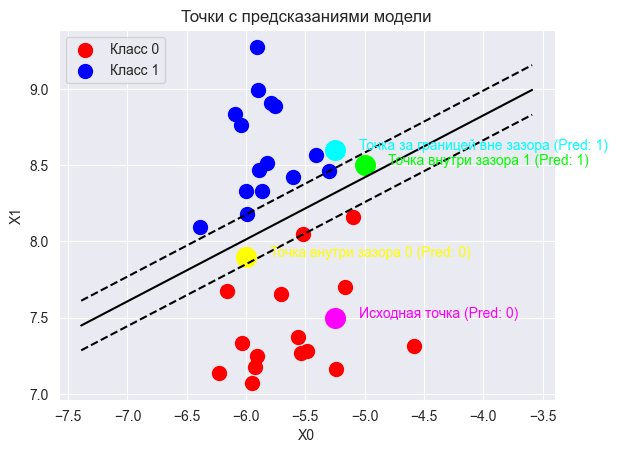

In [388]:
# Генерируем данные
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.4)

# Обучаем SVM
clf = SVC(kernel='linear', C=100)
clf.fit(X, y)

# Получаем параметры гиперплоскости
w, b = clf.coef_[0], clf.intercept_[0]
xx = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
decision_boundary = -(w[0] * xx + b) / w[1]
margin_pos = -(w[0] * xx + b + 1) / w[1]
margin_neg = -(w[0] * xx + b - 1) / w[1]

# Ваши точки с уникальными цветами и подписями
points = [
    {'coords': [-5.25, 7.5], 'label': 'Исходная точка', 'color': 'magenta', 'marker': 'o'},
    {'coords': [-5.25, 8.6], 'label': 'Точка за границей вне зазора', 'color': 'cyan', 'marker': 'o'},
    {'coords': [-5.0, 8.5], 'label': 'Точка внутри зазора 1', 'color': 'lime', 'marker': 'o'},
    {'coords': [-6.0, 7.9], 'label': 'Точка внутри зазора 0', 'color': 'yellow', 'marker': 'o'}
]

plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], c='red', s=100, label='Класс 0')
plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], c='blue', s=100, label='Класс 1')
plt.plot(xx, decision_boundary, 'k-')
plt.plot(xx, margin_pos, 'k--')
plt.plot(xx, margin_neg, 'k--')

# Для каждой точки выведем предсказание модели о классе
for pt in points:
    coords = pt['coords']
    pred_class = clf.predict([coords])[0]
    plt.scatter(coords[0], coords[1], c=pt['color'], s=200, marker=pt['marker'])
    plt.text(coords[0] + 0.2, coords[1],
             f"{pt['label']} (Pred: {pred_class})",
             fontsize=10, color=pt['color'])
    print(f"{pt['label']} по координатам {coords} — предсказанный класс: {pred_class}")

plt.legend()
plt.xlabel('X0')
plt.ylabel('X1')
plt.title('Точки с предсказаниями модели')
plt.show()

## 3. Анализ с дрругими видами ядер

Линейное ядро с зазором:


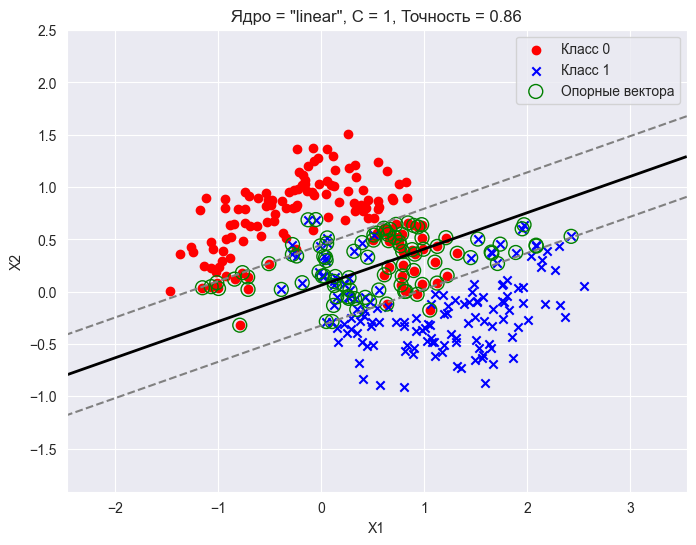

========================================================================>

Пересекающиеся классы с ядром 'rbf':


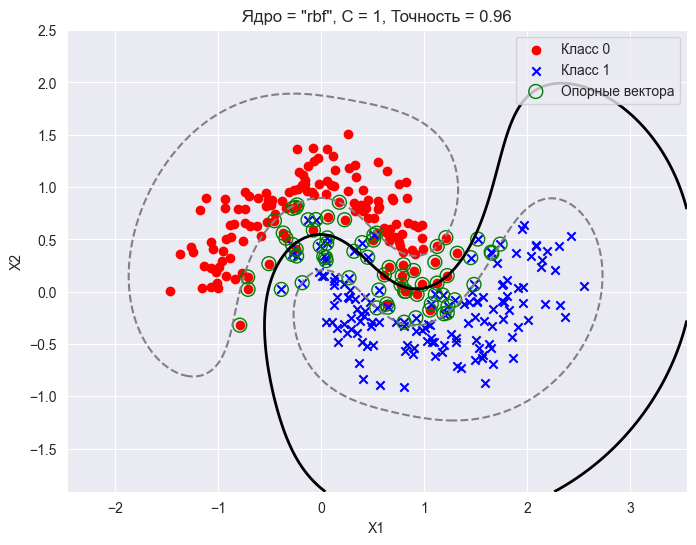

========================================================================>

Пересекающиеся классы с полиномиальным ядром:


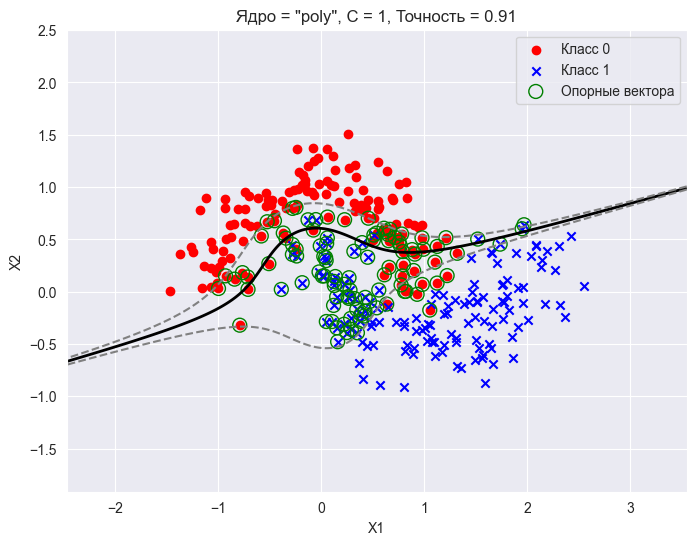

========================================================================>



In [389]:
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)


def train_and_plot(X, y, kernel_type, C_value=1.0):
    """Обучает SVM с указанным ядром, отображает границы и выводит точность"""
    svm = SVC(kernel=kernel_type, C=C_value)
    svm.fit(X, y)

    # Предсказания для оценки точности (на той же выборке)
    y_pred = svm.predict(X)
    accuracy = accuracy_score(y, y_pred)

    # Визуализация
    plt.figure(figsize=(8,6))
    plt.scatter(X[y==0][:,0], X[y==0][:,1], color='red', marker='o', label='Класс 0')
    plt.scatter(X[y==1][:,0], X[y==1][:,1], color='blue', marker='x', label='Класс 1')

    # Создаем сетку для отображения границ
    xx, yy = np.meshgrid(
        np.linspace(X[:,0].min()-1, X[:,0].max()+1, 500),
        np.linspace(X[:,1].min()-1, X[:,1].max()+1, 500)
    )
    Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Основная граница решения (decision boundary)
    plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
    # Линии зазора (margin)
    plt.contour(xx, yy, Z, levels=[-1, 1], linestyles='dashed', colors='grey')
    # Опорные векторы
    plt.scatter(svm.support_vectors_[:,0], svm.support_vectors_[:,1], s=100, facecolors='none', edgecolors='green', label='Опорные вектора')

    plt.legend()
    plt.title(f'Ядро = "{kernel_type}", C = {C_value}, Точность = {accuracy:.2f}')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.show()
    return svm, accuracy


# Анализ для линейно неразделимого с зазором
print("Линейное ядро с зазором:")
svm_linear_soft, acc_linear_soft = train_and_plot(X, y, 'linear', C_value=1)
print("========================================================================>")
print()

# Анализ для пересекающихся классов с ядром 'rbf'
print("Пересекающиеся классы с ядром 'rbf':")
svm_rbf, acc_rbf = train_and_plot(X, y, 'rbf', C_value=1)
print("========================================================================>")
print()

# Анализ для пересекающихся классов с полиномиальным ядром
print("Пересекающиеся классы с полиномиальным ядром:")
svm_poly, acc_poly = train_and_plot(X, y, 'poly', C_value=1)
print("========================================================================>")
print()

## 4. Изменение аргумента C для данных без зазора

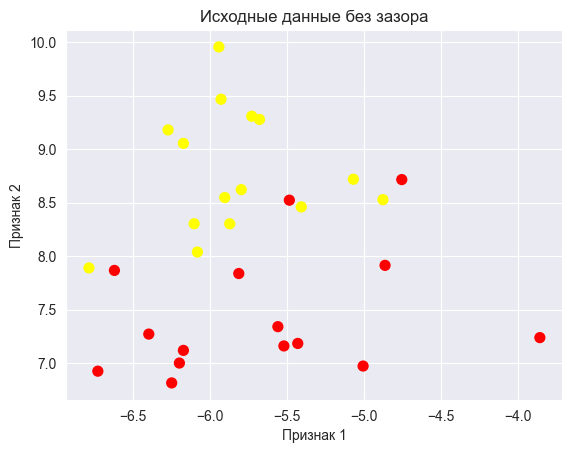


=========================================================>

Параметр C = 0.1
Количество опорных векторов: [15 15]



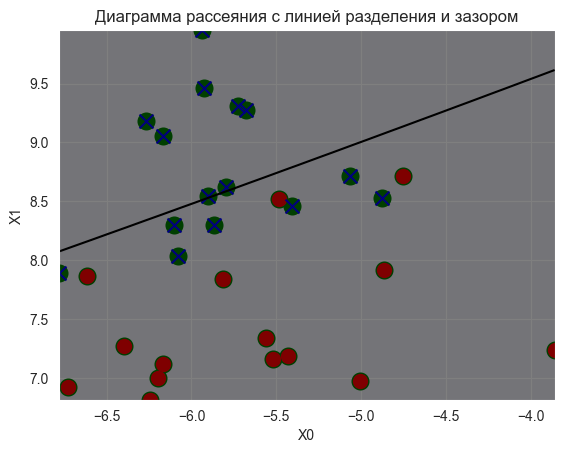


=========================================================>

Параметр C = 1
Количество опорных векторов: [10 11]



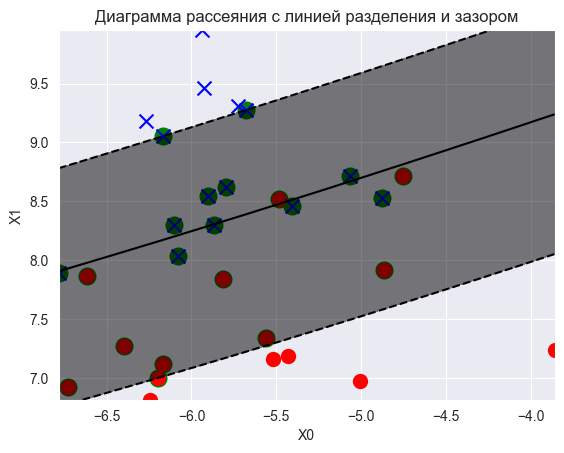


=========================================================>

Параметр C = 10
Количество опорных векторов: [6 6]



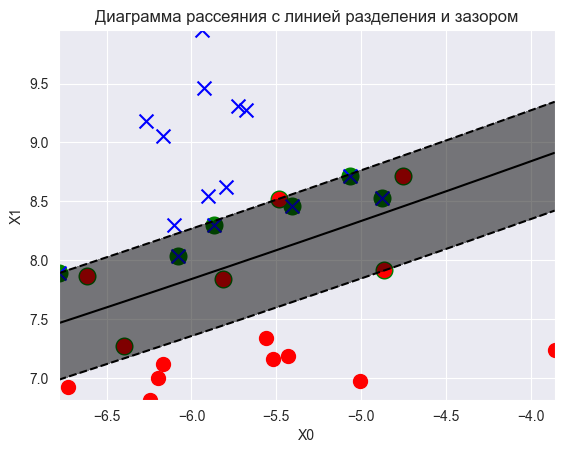


=========================================================>

Параметр C = 100
Количество опорных векторов: [5 5]



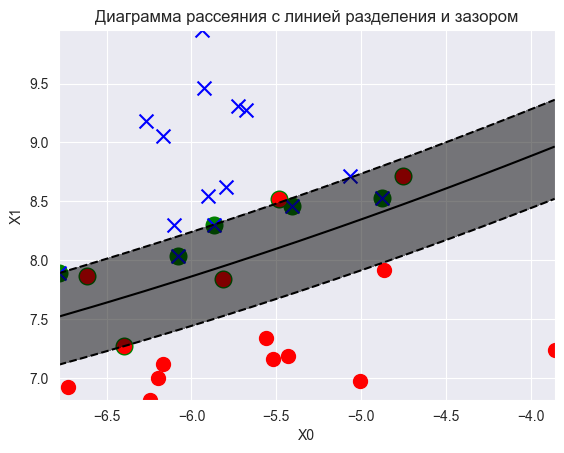


=========================================================>

Параметр C = 10000
Количество опорных векторов: [4 5]



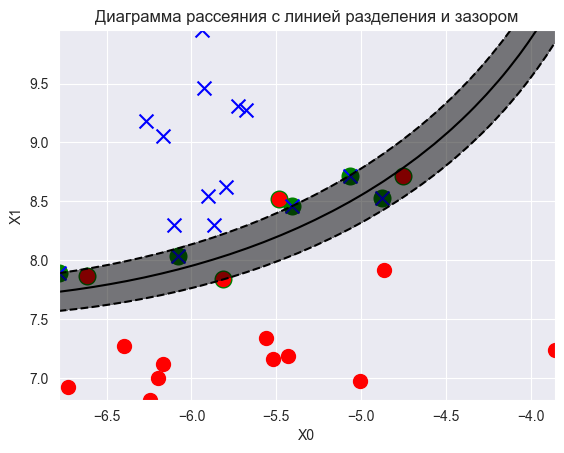

In [390]:
# 1. Генерируем данные без зазора
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.7)

# Визуализация исходных данных
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='autumn', s=50)
plt.title('Исходные данные без зазора')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.show()


C_values = [0.1, 1, 10, 100, 10000]

for C in C_values:
    # Создаем и обучаем модель с текущим C
    svm_poly = SVC(kernel='poly', degree=4, C=C)
    svm_poly.fit(X, y)
    print()
    print("=========================================================>")
    print()
    print(f"Параметр C = {C}")
    print(f"Количество опорных векторов: {svm_poly.n_support_}\n")

    # Визуализируем границу и линию зазора
    plot_decision_regions(X, y, svm_poly)


##  5. Классификатор без ядра LinearSVC для датасета без зазора между классами

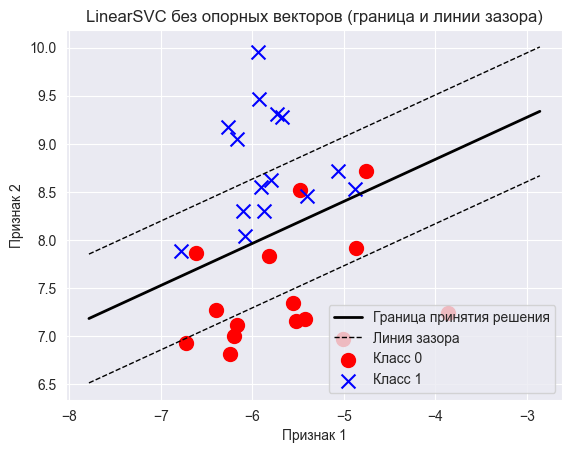

Точность модели: 0.900


In [391]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.7)

# Обучение LinearSVC
svm = LinearSVC(C=100)
svm.fit(X, y)

# Получение коэффициентов и свободного члена
w = svm.coef_[0]
b = svm.intercept_[0]

# Построение границы принятия решения
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
X_plot = np.linspace(x_min, x_max, 200)

# График границы
y_boundary = - (w[0] * X_plot + b) / w[1]
plt.plot(X_plot, y_boundary, color='black', linewidth=2, label='Граница принятия решения')

# Линии зазора (margin)
margin = 1 / np.linalg.norm(w)

# Верхняя и нижняя линии зазора
y_upper = y_boundary + np.sqrt(1 + 0) * margin
y_lower = y_boundary - np.sqrt(1 + 0) * margin

plt.plot(X_plot, y_upper, 'k--', linewidth=1, label='Линия зазора')
plt.plot(X_plot, y_lower, 'k--', linewidth=1)

# Визуализация точек
plt.scatter(X[y==0, 0], X[y==0, 1], color='red', marker='o', s=100, label='Класс 0')
plt.scatter(X[y==1, 0], X[y==1, 1], color='blue', marker='x', s=100, label='Класс 1')

plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('LinearSVC без опорных векторов (граница и линии зазора)') # Так как не хранит опорные вектора
plt.legend()
plt.show()


y_pred = svm.predict(X)
accuracy = accuracy_score(y, y_pred)
print(f'Точность модели: {accuracy:.3f}')

## 6. Подбор наилучшего метода опорных векторов с датасетом из 1000 точек и 5 атрибутов

In [392]:
# Генерируем датасет
X, y = make_classification(
    n_samples=1000, n_features=5, n_informative=3,
    n_redundant=0, n_clusters_per_class=1, flip_y=0.01,
    class_sep=1.0, random_state=42
)

# Задаем параметры для перебора
C_values = [0.1, 1, 10, 100]
kernels = ['linear', 'rbf', 'poly']
degrees = [3, 4, 5]

# Для хранения результатов
results = []

# Перебираем ядра
for kernel in kernels:
    if kernel == 'poly':
        for degree in degrees:
            for C in C_values:
                svc = SVC(kernel=kernel, degree=degree, C=C)
                scores = cross_val_score(svc, X, y, cv=5)
                mean_score = scores.mean()
                results.append({
                    'kernel': kernel,
                    'degree': degree,
                    'C': C,
                    'score': mean_score
                })
                print(f"Ядро: {kernel}, Степень: {degree}, C = {C} — точность: {mean_score:.3f}")
            print()
            print("-----------------------------------------------<")
            print()
    else:
        for C in C_values:
            svc = SVC(kernel=kernel, C=C)
            scores = cross_val_score(svc, X, y, cv=5)
            mean_score = scores.mean()
            results.append({
                'kernel': kernel,
                'C': C,
                'score': mean_score
            })
            print(f"Ядро: {kernel}, C = {C} — точность: {mean_score:.3f}")
        print()
        print()
        print("===================================================<")
        print()
        print()

# Находим лучший результат
best_result = max(results, key=lambda x: x['score'])

print("\nЛучшие параметры:")
if best_result['kernel'] == 'poly':
    print(f"Ядро: {best_result['kernel']}, Степень: {best_result['degree']}, C: {best_result['C']}")
else:
    print(f"Ядро: {best_result['kernel']}, C = {best_result['C']}")
print(f"Максимальная точность: {best_result['score']:.3f}")

Ядро: linear, C = 0.1 — точность: 0.921
Ядро: linear, C = 1 — точность: 0.923
Ядро: linear, C = 10 — точность: 0.923
Ядро: linear, C = 100 — точность: 0.923


===================================================<


Ядро: rbf, C = 0.1 — точность: 0.922
Ядро: rbf, C = 1 — точность: 0.936
Ядро: rbf, C = 10 — точность: 0.934
Ядро: rbf, C = 100 — точность: 0.934


===================================================<


Ядро: poly, Степень: 3, C = 0.1 — точность: 0.905
Ядро: poly, Степень: 3, C = 1 — точность: 0.916
Ядро: poly, Степень: 3, C = 10 — точность: 0.925
Ядро: poly, Степень: 3, C = 100 — точность: 0.925

-----------------------------------------------<

Ядро: poly, Степень: 4, C = 0.1 — точность: 0.822
Ядро: poly, Степень: 4, C = 1 — точность: 0.844
Ядро: poly, Степень: 4, C = 10 — точность: 0.855
Ядро: poly, Степень: 4, C = 100 — точность: 0.859

-----------------------------------------------<

Ядро: poly, Степень: 5, C = 0.1 — точность: 0.874
Ядро: poly, Степень: 5, C = 1 — точнос

## 7. Обучение модели на датасете с большим количеством точек

In [393]:
import time


t = 0
i = 5000
while t <= 10:
    X, y = make_classification(
        n_samples=i, n_features=5, n_informative=3,
        n_redundant=0, n_clusters_per_class=1, flip_y=0.01,
        class_sep=1.0, random_state=42
    )

    svc = SVC(kernel='rbf', C=1)

    start_time = time.perf_counter()

    svc.fit(X, y)

    end_time = time.perf_counter()

    t = end_time - start_time
    print(f"Точек - {i:6} штук   |    Время обучения модели: {t:.2f} секунд")
    i += 5000

Точек -   5000 штук   |    Время обучения модели: 0.08 секунд
Точек -  10000 штук   |    Время обучения модели: 0.14 секунд
Точек -  15000 штук   |    Время обучения модели: 0.55 секунд
Точек -  20000 штук   |    Время обучения модели: 0.26 секунд
Точек -  25000 штук   |    Время обучения модели: 1.35 секунд
Точек -  30000 штук   |    Время обучения модели: 1.94 секунд
Точек -  35000 штук   |    Время обучения модели: 1.93 секунд
Точек -  40000 штук   |    Время обучения модели: 3.62 секунд
Точек -  45000 штук   |    Время обучения модели: 3.27 секунд
Точек -  50000 штук   |    Время обучения модели: 6.86 секунд
Точек -  55000 штук   |    Время обучения модели: 7.81 секунд
Точек -  60000 штук   |    Время обучения модели: 6.88 секунд
Точек -  65000 штук   |    Время обучения модели: 7.03 секунд
Точек -  70000 штук   |    Время обучения модели: 13.59 секунд


## 8. Применение SVC на множественной классификации

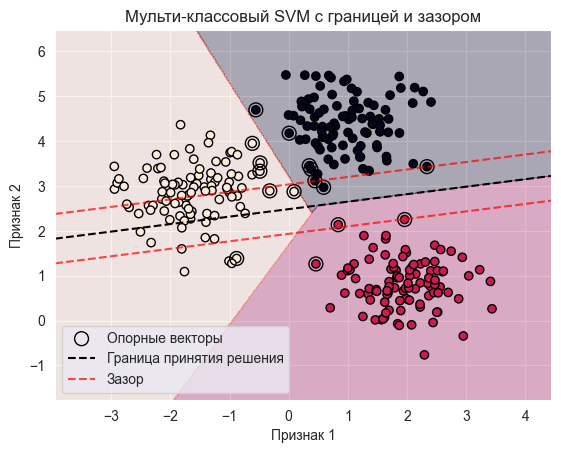

Точность модели =  1.0


In [398]:
# 1. Создадим датасет с 3 классами для визуализации
X, y = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)

# 2. Обучим SVM
clf = SVC(kernel='linear', decision_function_shape='ovr')
clf.fit(X, y)

# 3. Визуализация границ
# Создаем сетку точек для визуализации
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))
grid = np.c_[xx.ravel(), yy.ravel()]
pred = clf.predict(grid).reshape(xx.shape)

# 4. Визуализация
plt.contourf(xx, yy, pred, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', marker='o')

# 5. Добавим линии опорных векторов и границ
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
            facecolors='none', edgecolors='k', label='Опорные векторы')

# 6. Построим границы и зазор
# Получим коэффициенты линий, разделяющих классы, (для линейных)
w = clf.coef_[0]
b = clf.intercept_[0]

# линий границ
x_vals = np.linspace(x_min, x_max, 200)
# граница (decision boundary)
y_vals = -(w[0] / w[1]) * x_vals - b / w[1]
plt.plot(x_vals, y_vals, 'k--', label='Граница принятия решения')

# зазор
margin = 1 / np.linalg.norm(w)
y_margin_plus = -(w[0] / w[1]) * x_vals - (b / w[1]) + margin
y_margin_minus = -(w[0] / w[1]) * x_vals - (b / w[1]) - margin
plt.plot(x_vals, y_margin_plus, 'r--', alpha=0.7, label='Зазор')
plt.plot(x_vals, y_margin_minus, 'r--', alpha=0.7)

# 7. Подписываем и показываем
plt.legend()
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Мульти-классовый SVM с границей и зазором')
plt.show()

# 8. Метрики
accuracy = clf.score(X, y)
print("Точность модели = ", accuracy)


## 9. Моделирование опорными векторами на готовом датасете из библиотеки

Классы:  ['setosa' 'versicolor' 'virginica']

Точность модели: 0.82



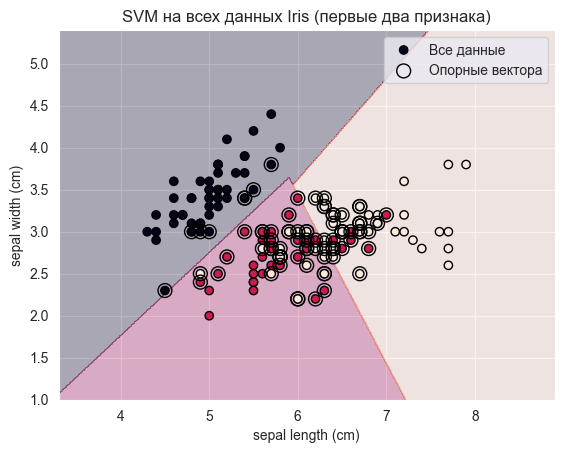

In [407]:
from sklearn import datasets


# Загрузка датасета iris
iris = datasets.load_iris()
print("Классы: ", iris.target_names)
print()
X = iris.data[:, :2]  # возьмем только 2 признака для визуализации
y = iris.target

# Обучаем SVM на всех данных
clf = SVC(kernel='linear', decision_function_shape='ovr')
clf.fit(X, y)

# Предсказываем для тех же данных
y_pred = clf.predict(X)

# Выводим точность
accuracy = np.mean(y_pred == y)
print(f'Точность модели: {accuracy:.2f}')
print()

# Визуализация границ решений
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))
grid_points = np.c_[xx.ravel(), yy.ravel()]
pred = clf.predict(grid_points).reshape(xx.shape)

plt.contourf(xx, yy, pred, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', label='Все данные')
plt.scatter(clf.support_vectors_[:,0], clf.support_vectors_[:,1],
            s=100, facecolors='none', edgecolors='k', label='Опорные вектора')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend()
plt.title('SVM на всех данных Iris (первые два признака)')
plt.show()

## 10. Анализ для задачи регрессии и соответствующего датасета

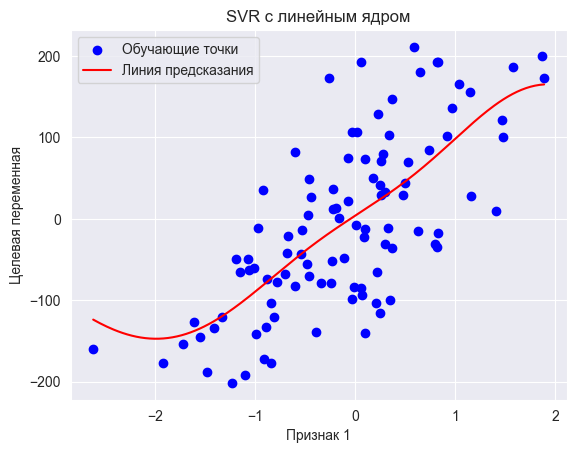

Коэффициент детерминации R^2: 0.9892491847868835


In [416]:
from sklearn.svm import SVR
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score


X, y = make_regression(n_samples=100, n_features=2, noise=10, random_state=42)

# Обучение регрессора SVR с линейным ядром
svr_linear = SVR(kernel='rbf', C=100)
svr_linear.fit(X, y)

# Создадим сетку для визуализации
X_plot = np.linspace(X[:, 0].min(), X[:, 0].max(), 200)

# Предсказываем значение для каждого X при фиксированном втором признаке
# Чтобы понять линию в двумерном признаковом пространстве,
# возьмем среднее значение второго признака
mean_feature2 = np.mean(X[:,1])
Y_pred = svr_linear.predict(np.column_stack([X_plot, mean_feature2 * np.ones_like(X_plot)]))

# Визуализация
plt.scatter(X[:, 0], y, color='blue', label='Обучающие точки')
plt.plot(X_plot, Y_pred, color='red', label='Линия предсказания')
plt.xlabel('Признак 1')
plt.ylabel('Целевая переменная')
plt.title('SVR с линейным ядром')
plt.legend()
plt.show()


y_pred = svr_linear.predict(X)
r2 = r2_score(y, y_pred)
print(f"Коэффициент детерминации R^2: {r2}")